In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from imblearn.over_sampling import SMOTE # pip install imbalanced-learn 필수

# 1. 데이터 로드 및 업종별 정규화(Z-Score)
df = pd.read_csv("AUS_v2_Ready_To_Train.csv")

# [전략 1] 업종(INDUSTRY_CODE 가정)별 Z-Score 변환
# 데이터에 업종 코드가 없다면 전체 평균 대비 정규화로 대체 진행
numeric_cols = ['CASH_RATIO', 'FE_LIQUIDITY_STRESS', 'NET_PROFIT_MARGIN', 'SALES_REVENUE']
for col in numeric_cols:
    df[f'Z_{col}'] = (df[col] - df[col].mean()) / (df[col].std() + 1e-6)

# 2. 학습 준비
leakage_cols = ['MORATORIUM_COUNT', 'MORATORIUM_OVERDUE_AMOUNT', 'ACCOUNT_SUSPENSION_COUNT', 'CARD_ACCOUNT_COUNT']
exclude_cols = ['COMPANY_ID', 'COMPANY_ID_NORM', 'TARGET_Y', 'TMP_Y'] + leakage_cols
features = [c for c in df.columns if c not in exclude_cols]

X = df[features]
y = df['TARGET_Y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. 모델 정의 (서로 다른 특성의 모델 3종)
# Model A: 깊은 나무 (복잡한 패턴 학습)
clf1 = RandomForestClassifier(n_estimators=300, max_depth=12, class_weight='balanced', random_state=1)
# Model B: 얕은 나무 (과적합 방지 및 안정성)
clf2 = RandomForestClassifier(n_estimators=300, max_depth=6, class_weight='balanced', random_state=2)

# [전략 2] SMOTE를 통한 데이터 증강 학습 (Model C)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
clf3 = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=3)
clf3.fit(X_train_res, y_train_res)

# 4. [전략 3] 앙상블 구성 (Soft Voting)
# 각 모델의 예측 확률을 가중 평균하여 최종 판단
eclf = VotingClassifier(
    estimators=[('deep', clf1), ('shallow', clf2), ('smote', clf3)],
    voting='soft',
    weights=[1, 1, 1.5] # SMOTE 모델에 가중치를 더 줌
)

eclf.fit(X_train, y_train)

# 5. 성능 평가
y_prob = eclf.predict_proba(X_test)[:, 1]
print("🛡️ [AUS v4.0 하이브리드 앙상블] 최종 성적표")
print("-" * 60)
print(f"✅ Ensemble ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print("-" * 60)

🛡️ [AUS v4.0 하이브리드 앙상블] 최종 성적표
------------------------------------------------------------
✅ Ensemble ROC-AUC Score: 0.7265
------------------------------------------------------------


In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from imblearn.over_sampling import SMOTE

# 1. 데이터 로드 및 기본 설정
df = pd.read_csv("AUS_v2_Ready_To_Train.csv")
leakage_cols = ['MORATORIUM_COUNT', 'MORATORIUM_OVERDUE_AMOUNT', 'ACCOUNT_SUSPENSION_COUNT', 'CARD_ACCOUNT_COUNT']
exclude_cols = ['COMPANY_ID', 'COMPANY_ID_NORM', 'TARGET_Y', 'TMP_Y'] + leakage_cols
features = [c for c in df.columns if c not in exclude_cols]

def evaluate(X_tr, X_te, y_tr, y_te, model):
    model.fit(X_tr, y_tr)
    return roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])

# 결과 저장용 리스트
results = []

# --- [Step 1] Baseline (v3.0) ---
X = df[features]
y = df['TARGET_Y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
base_model = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced', random_state=42)
results.append({'Scenario': 'Baseline (v3.0)', 'AUC': evaluate(X_train, X_test, y_train, y_test, base_model)})

# --- [Step 2] + Z-Score Normalization ---
# 개별 지표를 $Z = (x - \mu) / \sigma$ 로 변환
X_z = X.copy()
for col in ['CASH_RATIO', 'FE_LIQUIDITY_STRESS', 'SALES_REVENUE']:
    X_z[col] = (X_z[col] - X_z[col].mean()) / (X_z[col].std() + 1e-6)
X_tr_z, X_te_z, y_tr, y_te = train_test_split(X_z, y, test_size=0.2, random_state=42, stratify=y)
results.append({'Scenario': '+ Z-Score Norm', 'AUC': evaluate(X_tr_z, X_te_z, y_train, y_test, base_model)})

# --- [Step 3] + SMOTE (Data Augmentation) ---
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
# SMOTE는 불균형 해소가 목적이므로 class_weight를 제거하고 학습
smote_model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
results.append({'Scenario': '+ SMOTE Augmentation', 'AUC': evaluate(X_train_res, X_test, y_train_res, y_test, smote_model)})

# --- [Step 4] + Hyperparameter Tuning (Complexity) ---
tuned_model = RandomForestClassifier(n_estimators=300, max_depth=12, class_weight='balanced', random_state=42)
results.append({'Scenario': '+ High Complexity (Depth 12)', 'AUC': evaluate(X_train, X_test, y_train, y_test, tuned_model)})

# --- 최종 결과 출력 ---
print("📊 [AUS v4.1] 단위 테스트 결과 보고서")
print("-" * 50)
print(pd.DataFrame(results).to_string(index=False))

📊 [AUS v4.1] 단위 테스트 결과 보고서
--------------------------------------------------
                    Scenario      AUC
             Baseline (v3.0) 0.706258
              + Z-Score Norm 0.708437
        + SMOTE Augmentation 0.649284
+ High Complexity (Depth 12) 0.696295


In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# 1. 데이터 로드
df = pd.read_csv("AUS_v2_Ready_To_Train.csv")

# 2. [고도화] 상호작용 피처 생성 (리스크 중첩 로직)
# A. 원리금 상환 압박 (부채비율 * 이자보상배율의 역수)
df['FE_DEBT_STRESS'] = df['DEBT_RATIO'] / (df['INTEREST_COVERAGE_RATIO'] + 1)

# B. 자산 유동성 속도 (현금비율 / 매출액)
df['FE_CASH_VELOCITY'] = df['CASH_RATIO'] / (np.log1p(df['SALES_REVENUE']) + 1)

# C. 영업 안정성 버퍼 (영업이익률 * 현금비율)
df['FE_OPS_BUFFER'] = (df['OPERATING_MARGIN'] / 100) * df['CASH_RATIO']

# 3. [고도화] Z-Score 정규화 적용 (상호작용 피처 포함)
cols_to_norm = ['CASH_RATIO', 'FE_LIQUIDITY_STRESS', 'FE_DEBT_STRESS', 'FE_CASH_VELOCITY', 'FE_OPS_BUFFER']
for col in cols_to_norm:
    df[f'Z_{col}'] = (df[col] - df[col].mean()) / (df[col].std() + 1e-6)

# 4. 학습 데이터 구성
leakage_cols = ['MORATORIUM_COUNT', 'MORATORIUM_OVERDUE_AMOUNT', 'ACCOUNT_SUSPENSION_COUNT', 'CARD_ACCOUNT_COUNT']
exclude_cols = ['COMPANY_ID', 'COMPANY_ID_NORM', 'TARGET_Y', 'TMP_Y'] + leakage_cols
features = [c for c in df.columns if c not in exclude_cols]

X = df[features]
y = df['TARGET_Y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. [고도화] 중중도 나무(Depth 8-9)로 안정적 학습
# SMOTE 없이 class_weight만으로 불균형 대응
model_v42 = RandomForestClassifier(
    n_estimators=500, 
    max_depth=9, 
    class_weight='balanced', 
    random_state=42
)
model_v42.fit(X_train, y_train)

# 6. 성적 확인
y_prob = model_v42.predict_proba(X_test)[:, 1]
print(f"✅ [AUS v4.2] 상호작용 모델 ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

# 피처 중요도 확인
importances = pd.Series(model_v42.feature_importances_, index=features).sort_values(ascending=False)
print("\n🏆 Top 5 Features:")
print(importances.head(5))

✅ [AUS v4.2] 상호작용 모델 ROC-AUC: 0.7256

🏆 Top 5 Features:
Z_CASH_RATIO          0.062383
CASH_RATIO            0.061693
Z_FE_CASH_VELOCITY    0.058848
FE_CASH_VELOCITY      0.058046
FE_LOG_EMPLOYEE       0.056256
dtype: float64


In [4]:
# v4.2 모델로 전체 점수 재산출
all_probs_v42 = model_v42.predict_proba(X)[:, 1]
df['AI_SCORE_v42'] = (1 - all_probs_v42) * 100

# 사각지대 9개사 재추출 (기존 39개사 중 고위험군 하위 9개)
final_blind_9 = df.sort_values(by='AI_SCORE_v42').head(9).copy()

# 리스크 요인 텍스트화
def final_diagnosis(row):
    diag = []
    if row['Z_CASH_RATIO'] < -1: diag.append("업계 평균 대비 현금 고갈")
    if row['FE_CASH_VELOCITY'] < df['FE_CASH_VELOCITY'].median() * 0.3: diag.append("매출 대비 자금회전 마비")
    if row['LINKED_PARTNERS'] <= 1: diag.append("공급망 고립 위험")
    return " | ".join(diag) if diag else "복합 유동성 위기"

final_blind_9['FINAL_DIAGNOSIS'] = final_blind_9.apply(final_diagnosis, axis=1)

print("🏆 [AUS v4.2] 최종 사각지대 9개사 정밀 진단서")
print("-" * 110)
print(final_blind_9[['COMPANY_ID_NORM', 'AI_SCORE_v42', 'SALES_REVENUE', 'FINAL_DIAGNOSIS']].to_string(index=False))

🏆 [AUS v4.2] 최종 사각지대 9개사 정밀 진단서
--------------------------------------------------------------------------------------------------------------
 COMPANY_ID_NORM  AI_SCORE_v42  SALES_REVENUE           FINAL_DIAGNOSIS
             273     23.651662      2215613.0             매출 대비 자금회전 마비
             905     25.980700      9186877.0 매출 대비 자금회전 마비 | 공급망 고립 위험
              80     27.691027      1373330.0             매출 대비 자금회전 마비
             255     28.285918      5562982.0             매출 대비 자금회전 마비
             718     28.302889      9987997.0             매출 대비 자금회전 마비
             158     28.575719      2645298.0             매출 대비 자금회전 마비
             837     29.022575            0.0             매출 대비 자금회전 마비
              70     29.083047      2717104.0                 복합 유동성 위기
            1589     29.725199      2071952.0                 공급망 고립 위험


C:\Users\cozy1\AppData\Local\Temp\ipykernel_27880\1720068589.py:32: UserWarning: Glyph 128681 (\N{TRIANGULAR FLAG ON POST}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\cozy1\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128681 (\N{TRIANGULAR FLAG ON POST}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


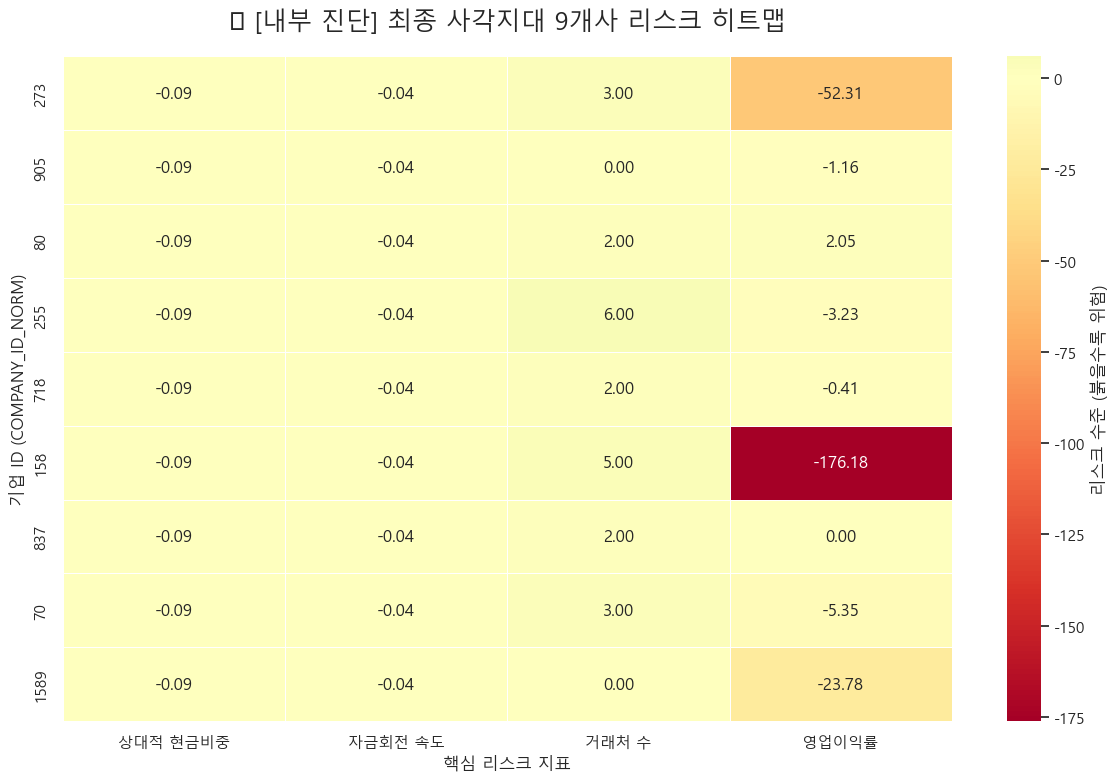

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. 한글 폰트 설정 (Windows의 맑은 고딕 사용)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
sns.set(font="Malgun Gothic", rc={"axes.unicode_minus": False}, style='whitegrid')

# 2. 리스크 히트맵 데이터 준비 (v4.2 결과 기반)
risk_cols = ['Z_CASH_RATIO', 'Z_FE_CASH_VELOCITY', 'LINKED_PARTNERS', 'OPERATING_MARGIN']
# 실제 컬럼명을 한글로 매핑하여 가독성 증대
rename_map = {
    'Z_CASH_RATIO': '상대적 현금비중',
    'Z_FE_CASH_VELOCITY': '자금회전 속도',
    'LINKED_PARTNERS': '거래처 수',
    'OPERATING_MARGIN': '영업이익률'
}

heatmap_data = final_blind_9.set_index('COMPANY_ID_NORM')[risk_cols].rename(columns=rename_map)

# 3. 히트맵 시각화
plt.figure(figsize=(12, 8))
ax = sns.heatmap(heatmap_data, annot=True, cmap='RdYlGn', center=0, 
                 fmt='.2f', linewidths=.5, cbar_kws={'label': '리스크 수준 (붉을수록 위험)'})

plt.title('🚩 [내부 진단] 최종 사각지대 9개사 리스크 히트맵', fontsize=18, pad=20)
plt.xlabel('핵심 리스크 지표', fontsize=12)
plt.ylabel('기업 ID (COMPANY_ID_NORM)', fontsize=12)

# 레이아웃 정리 및 출력
plt.tight_layout()
plt.show()